# B15 — Single-Qubit Gates in Qiskit

**Track B — the SDK.** A03 built every single-qubit gate by hand in NumPy and
showed that each one is a rotation of the Bloch sphere. This notebook does the
same tour through Qiskit, and the checkpoint at the bottom asserts that the two
routes produce *identical* matrices — not similar, identical.

---

## Where we are

| Track A (A03, by hand) | Qiskit |
|---|---|
| `X = np.array([[0,1],[1,0]])` | `qc.x(0)`, or `XGate()` |
| `Rz(t) = cos(t/2) I - i sin(t/2) Z` | `qc.rz(t, 0)` |
| the matrix itself | `Operator(qc).data` |
| `np.allclose(A, B)` | `Operator(A) == Operator(B)` |
| `same_up_to_phase(A, B)` (we wrote it) | `Operator(A).equiv(Operator(B))` |
| `bloch_rotation(U)` | *(still by hand — `qviz` may only draw)* |

That fifth row is the whole notebook.

## The one thing to take away

Qiskit gives you **two** ways to compare gates, and they disagree:

```python
Operator(rz_circuit) == Operator(p_circuit)        # False
Operator(rz_circuit).equiv(Operator(p_circuit))    # True
```

$R_z(\theta) = \mathrm{diag}(e^{-i\theta/2}, e^{i\theta/2})$ and
$P(\theta) = \mathrm{diag}(1, e^{i\theta})$ differ by the overall factor
$e^{-i\theta/2}$ — a **global phase**. `==` compares numbers and says no. `equiv`
compares *physics* and says yes, because no measurement anywhere can distinguish
$|\psi\rangle$ from $e^{i\varphi}|\psi\rangle$.

Qiskit is not being sloppy by offering both. It is encoding a belief about the
world into an API: global phase is not data. And then — this is the part every
tutorial skips — it hands you `.control()`, which makes that belief false. A
controlled gate applies $U$ on one branch of a superposition and not the other,
so $U$'s "global" phase becomes a **relative** phase between branches, which is
measurable. Section 6 measures it.

## A warning that will save you hours

This repo pins **Qiskit 2.5**. If you have seen `from qiskit import execute`,
`Aer.get_backend('qasm_simulator')`, `qiskit.opflow` or `.c_if(...)` in a
tutorial, every one of them now raises. `CLAUDE.md` has the full list and the
build gate greps for all of it, so nothing stale can ship here.

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.circuit.library import (HGate, IGate, PhaseGate, RXGate, RYGate,
                                    RZGate, SdgGate, SGate, TdgGate, TGate,
                                    UGate, XGate, YGate, ZGate)
from qiskit.quantum_info import Operator, Statevector
from qiskit.synthesis import OneQubitEulerDecomposer

style.use()

SEED = backends.seed_for("B15")
rng = np.random.default_rng(SEED)
print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260819


## 1. `Operator` is the bridge from circuit to matrix

A `QuantumCircuit` is a *recipe*. `Operator(qc)` executes that recipe
symbolically and hands back the $2^n \times 2^n$ unitary it implements — the
object A03 spent its entire length building by hand.

Below: the fourteen standard single-qubit gates, each as a one-gate circuit,
each turned into a matrix by `Operator`, each compared against the literal
NumPy array A03 wrote down. The `matches A03` column is the point.

Two conventions worth naming before the numbers, because both are places where
code runs happily while being wrong:

- `qc.rz(t, 0)` is $\mathrm{diag}(e^{-it/2}, e^{it/2})$ — the *symmetric*
  convention, with the phase split evenly between the two levels. `qc.p(t, 0)`
  puts all of it on $|1\rangle$. Neither is more correct; they are different
  conventions for the same rotation.
- `qc.u(θ, φ, λ)` is Qiskit's universal single-qubit gate,
  $$U(\theta,\phi,\lambda)=\begin{pmatrix}\cos\tfrac{\theta}{2} &
  -e^{i\lambda}\sin\tfrac{\theta}{2}\\ e^{i\phi}\sin\tfrac{\theta}{2} &
  e^{i(\phi+\lambda)}\cos\tfrac{\theta}{2}\end{pmatrix},$$
  and Section 7 shows that *every* gate in the table is a special case of it.

In [2]:
# --- the A03 matrices, transcribed by hand. Qiskit is not involved here. -----
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (X + Z) / np.sqrt(2)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)


def dag(M):
    return np.asarray(M).conj().T


def rot(P, theta):
    """exp(-i theta P / 2) = cos(theta/2) I - i sin(theta/2) P, for P^2 = I."""
    return np.cos(theta / 2) * I2 - 1j * np.sin(theta / 2) * np.asarray(P)


def P_gate(theta):
    return np.array([[1, 0], [0, np.exp(1j * theta)]], dtype=complex)


def U_gate(theta, phi, lam):
    """Qiskit's universal single-qubit gate, written out by hand."""
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -np.exp(1j * lam) * s],
                     [np.exp(1j * phi) * s, np.exp(1j * (phi + lam)) * c]],
                    dtype=complex)


# --- the same fourteen gates as Qiskit circuits ------------------------------
TH = 2 * np.pi / 3          # a deliberately non-special angle
CATALOGUE = [
    ("I",        lambda q: q.id(0),                 I2),
    ("X",        lambda q: q.x(0),                  X),
    ("Y",        lambda q: q.y(0),                  Y),
    ("Z",        lambda q: q.z(0),                  Z),
    ("H",        lambda q: q.h(0),                  H),
    ("S",        lambda q: q.s(0),                  S),
    ("Sdg",      lambda q: q.sdg(0),                dag(S)),
    ("T",        lambda q: q.t(0),                  T),
    ("Tdg",      lambda q: q.tdg(0),                dag(T)),
    ("RX(2pi/3)", lambda q: q.rx(TH, 0),            rot(X, TH)),
    ("RY(2pi/3)", lambda q: q.ry(TH, 0),            rot(Y, TH)),
    ("RZ(2pi/3)", lambda q: q.rz(TH, 0),            rot(Z, TH)),
    ("P(2pi/3)",  lambda q: q.p(TH, 0),             P_gate(TH)),
    ("U(.4,.5,.6)", lambda q: q.u(0.4, 0.5, 0.6, 0), U_gate(0.4, 0.5, 0.6)),
]


def one_gate(build):
    """A one-qubit circuit carrying a single gate."""
    qc = QuantumCircuit(1)
    build(qc)
    return qc


print(f"{'gate':>12} {'Operator(qc).data':>34}  {'unitary?':>8}  matches A03")
for name, build, hand in CATALOGUE:
    M = Operator(one_gate(build)).data
    top = f"[{M[0,0]:+.3f} {M[0,1]:+.3f}]"
    print(f"{name:>12} {top:>34}  "
          f"{str(np.allclose(dag(M) @ M, I2)):>8}  "
          f"{np.allclose(M, hand)}")
    print(f"{'':>12} {f'[{M[1,0]:+.3f} {M[1,1]:+.3f}]':>34}")

print("\nall fourteen agree with the hand-written A03 matrices:",
      all(np.allclose(Operator(one_gate(b)).data, h) for _, b, h in CATALOGUE))

        gate                  Operator(qc).data  unitary?  matches A03
           I      [+1.000+0.000j +0.000+0.000j]      True  True
                  [+0.000+0.000j +1.000+0.000j]
           X      [+0.000+0.000j +1.000+0.000j]      True  True
                  [+1.000+0.000j +0.000+0.000j]
           Y      [+0.000+0.000j +0.000-1.000j]      True  True
                  [+0.000+1.000j +0.000+0.000j]
           Z      [+1.000+0.000j +0.000+0.000j]      True  True
                  [+0.000+0.000j -1.000+0.000j]
           H      [+0.707+0.000j +0.707+0.000j]      True  True
                  [+0.707+0.000j -0.707+0.000j]
           S      [+1.000+0.000j +0.000+0.000j]      True  True
                  [+0.000+0.000j +0.000+1.000j]
         Sdg      [+1.000+0.000j +0.000+0.000j]      True  True
                  [+0.000+0.000j +0.000-1.000j]
           T      [+1.000+0.000j +0.000+0.000j]      True  True
                  [+0.000+0.000j +0.707+0.707j]
         Tdg      [+1.000+0.000j 

Every row matches. That is not a coincidence to be pleased about — it is the
contract this repo runs on. Track A and Track B compute the same numbers by
different routes, and every Track B notebook ends by asserting it.

Note `Operator` never had to *simulate* anything. It composed matrices, exactly
as we did. For one qubit that is free; for twelve it is a $4096\times4096$ dense
array and you should stop.

### Figure 1 — the twelve-gate contact sheet

A03's claim was that **every single-qubit gate is a rotation of the Bloch
sphere**. Here is that claim as a contact sheet: twelve gates, twelve panels,
each one showing what the gate does to the *same* starting state.

In each panel the violet rod is the rotation axis $\hat n$, the dashed ring is
the full orbit the state is committed to, and the arrows are before (grey) and
after (orange). The blue arc is the part actually traversed, fading towards the
past.

The axis and angle are extracted from `Operator(qc).data` by the small function
below — `qviz` may only draw, so the physics stays in the notebook where you can
read it. The starting state is deliberately *generic* rather than $|0\rangle$:
the north pole sits on the $z$ axis, so $Z$, $S$, $T$ and $R_z$ would all leave
it exactly where it is and four of the twelve panels would show nothing.

Three things to look for:

- **$I$ has no axis at all.** Angle zero, nothing moves. It is in the sheet
  because "do nothing" being a rotation is what makes the rotations a *group*.
- **$Z$, $S$, $T$ share an axis** and differ only in angle: $\pi$, $\pi/2$,
  $\pi/4$. The daggered versions turn the same amount the other way.
- **$H$'s axis is tilted.** It is the diagonal $(\hat x + \hat z)/\sqrt2$, and
  the angle is exactly $\pi$. "Hadamard makes a superposition" is a description
  of one input; "half-turn about a tilted axis" is what the gate *is*, and it
  makes $H^2 = I$ obvious rather than memorable.

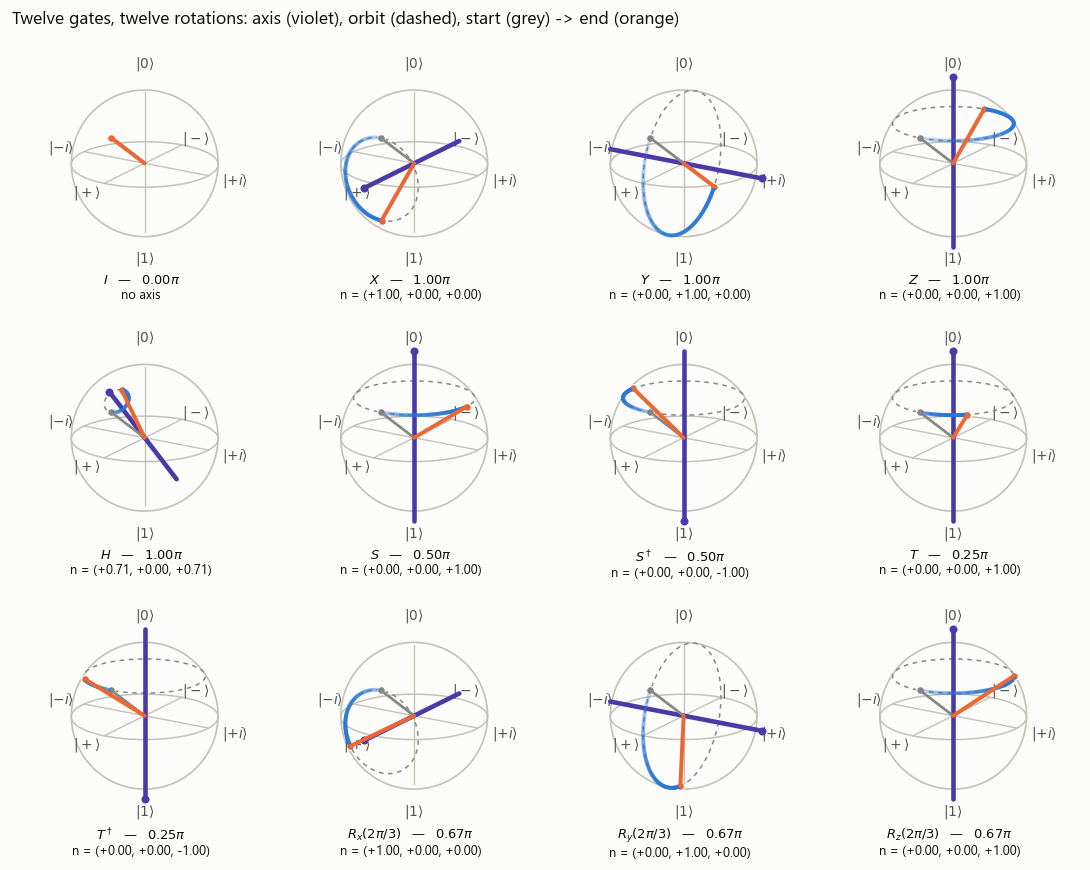

       gate                 axis n_hat      angle   R orthogonal?   det R
          I                 [0.,0.,1.]    0.000 pi            True   +1.000000
          X                 [1.,0.,0.]    1.000 pi            True   +1.000000
          Y                 [0.,1.,0.]    1.000 pi            True   +1.000000
          Z                 [0.,0.,1.]    1.000 pi            True   +1.000000
          H        [0.707,0.   ,0.707]    1.000 pi            True   +1.000000
          S                 [0.,0.,1.]    0.500 pi            True   +1.000000
        Sdg              [ 0., 0.,-1.]    0.500 pi            True   +1.000000
          T                 [0.,0.,1.]    0.250 pi            True   +1.000000
        Tdg              [ 0., 0.,-1.]    0.250 pi            True   +1.000000
  RX(2pi/3)                 [1.,0.,0.]    0.667 pi            True   +1.000000
  RY(2pi/3)                 [0.,1.,0.]    0.667 pi            True   +1.000000
  RZ(2pi/3)                 [0.,0.,1.]    0.667 pi       

In [3]:
# ---- physics, computed in the notebook (qviz draws, it does not derive) -----
def bloch_vector(state):
    """r = (<X>, <Y>, <Z>) for a normalized 2-vector."""
    s = np.asarray(state, dtype=complex)
    return np.array([np.vdot(s, P @ s).real for P in (X, Y, Z)])


def bloch_rotation(U):
    """The real 3x3 rotation with r' = R r.  R_ij = Tr(P_i U P_j U*)/2."""
    P = (X, Y, Z)
    return np.array([[0.5 * np.trace(P[i] @ U @ P[j] @ dag(U)).real
                      for j in range(3)] for i in range(3)])


def axis_angle(U):
    """(n_hat, theta) with U = e^{i phi} R_n(theta). Same routine as A03."""
    V = np.asarray(U) / np.sqrt(np.linalg.det(U))       # into SU(2)
    c = np.trace(V).real / 2
    if c < 0:                                            # fix the sqrt branch
        V, c = -V, -c
    theta = 2 * np.arccos(np.clip(c, -1.0, 1.0))
    s = np.sin(theta / 2)
    if abs(s) < 1e-12:
        return np.array([0.0, 0.0, 1.0]), 0.0
    nvec = np.array([(1j * np.trace(P @ V) / (2 * s)).real for P in (X, Y, Z)])
    return nvec / np.linalg.norm(nvec), theta


def rodrigues(nvec, t, v):
    """Rotate v about unit axis n by angle t."""
    nvec = np.asarray(nvec, float) / np.linalg.norm(nvec)
    v = np.asarray(v, float)
    return (v * np.cos(t) + np.cross(nvec, v) * np.sin(t)
            + nvec * np.dot(nvec, v) * (1 - np.cos(t)))


def bloch_frame(ax, labels=True, zoom=1.5):
    """Outline Bloch sphere - same helper A03 uses, and for the same reasons.

    An outline keeps twelve small panels from turning into mud, and a shaded
    surface is a smooth gradient over thousands of pixels that roughly doubles
    the PNG. This repo ships its notebooks with outputs committed, so bytes are
    a real constraint. The rim is the silhouette great circle for qviz.bloch's
    fixed camera (elev=18, azim=32).
    """
    bloch.sphere(ax, labels=labels, wire=False, alpha=0.0)
    e, a = np.deg2rad(18.0), np.deg2rad(32.0)
    view = np.array([np.cos(e) * np.cos(a), np.cos(e) * np.sin(a), np.sin(e)])
    u1 = np.cross(view, [0.0, 0.0, 1.0])
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(view, u1)
    t = np.linspace(0, 2 * np.pi, 160)
    p = np.outer(np.cos(t), u1) + np.outer(np.sin(t), u2)
    ax.plot(p[:, 0], p[:, 1], p[:, 2], color=style.AXIS, lw=1.1, zorder=1)
    ax.set_box_aspect((1, 1, 1), zoom=zoom)
    return ax


SHEET = CATALOGUE[:12]        # the 12 named gates; P and U get their own sections
TEX = [r"$I$", r"$X$", r"$Y$", r"$Z$", r"$H$", r"$S$", r"$S^\dagger$",
       r"$T$", r"$T^\dagger$", r"$R_x(2\pi/3)$", r"$R_y(2\pi/3)$",
       r"$R_z(2\pi/3)$"]

# A generic start: |0> rotated 55 deg off the pole, so no gate is invisible.
start_sv = Statevector(one_gate(lambda q: q.ry(np.deg2rad(55), 0)))
r0 = bloch_vector(start_sv.data)

fig, axes = grid.frames(12, ncols=4, panel=(2.45, 2.60), projection="3d")
for ax, tex, (name, build, _) in zip(axes, TEX, SHEET):
    U = Operator(one_gate(build)).data
    nv, th = axis_angle(U)
    bloch_frame(ax, zoom=1.44)

    if th > 1e-9:
        ax.plot(*np.array([-1.22 * nv, 1.22 * nv]).T, color=style.VIOLET,
                lw=3.0, zorder=4, solid_capstyle="round")
        ax.scatter(*(1.22 * nv), color=style.VIOLET, s=18, depthshade=False,
                   zorder=5)
        ring = np.array([rodrigues(nv, t, r0)
                         for t in np.linspace(0, 2 * np.pi, 160)])
        ax.plot(ring[:, 0], ring[:, 1], ring[:, 2], color=style.MUTED, lw=1.0,
                ls=(0, (3, 3)), zorder=3)
        arc = np.array([rodrigues(nv, t, r0) for t in np.linspace(0, th, 60)])
        bloch.path(ax, arc, color=style.BLUE, lw=2.6)

    bloch.vector(ax, r0, color=style.MUTED, lw=1.8)
    bloch.vector(ax, rodrigues(nv, th, r0), color=style.ORANGE, lw=2.6)
    axis_txt = ("no axis" if th < 1e-9 else
                "n = ({:+.2f}, {:+.2f}, {:+.2f})".format(*nv))
    bloch.label(ax, tex + rf"   —   ${th/np.pi:.2f}\pi$" + "\n" + axis_txt,
                y=0.09, size=8.5)

fig.suptitle("Twelve gates, twelve rotations: axis (violet), orbit (dashed), "
             "start (grey) -> end (orange)", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'gate':>11} {'axis n_hat':>26} {'angle':>10}   R orthogonal?   det R")
for tex, (name, build, _) in zip(TEX, SHEET):
    U = Operator(one_gate(build)).data
    nv, th = axis_angle(U)
    R = bloch_rotation(U)
    print(f"{name:>11} {np.array2string(np.round(nv, 3), separator=','):>26} "
          f"{th/np.pi:8.3f} pi   "
          f"{str(np.allclose(R.T @ R, np.eye(3), atol=1e-10)):>13}   "
          f"{np.linalg.det(R):+.6f}")

Every one: orthogonal, determinant $+1$, a rotation. Not one exception in the
sheet, and the checkpoint extends the claim to two hundred random unitaries.

The $S^\dagger$ and $T^\dagger$ panels are worth a second look. They are the
same axis as $S$ and $T$ with the arc running the other way — a dagger is a
gate run backwards, which for a rotation means negating the angle. That is
`axis_angle` reporting $\theta$ in $[0,\pi]$ with a flipped $\hat n$ rather than
a negative angle, which is the same rotation said differently.

## 2. `Operator.equiv` — the heatmap that finds the identities

### Figure 2 — sixteen expressions, compared two ways

Here is the payoff of having gates as matrices: you can ask whether two circuits
are the same *gate* without knowing anything about what they do.

Sixteen expressions — plain gates and short products — compared pairwise, twice:

| comparison | question it asks | Qiskit |
|---|---|---|
| exact | are the matrices the same numbers? | `A == B` |
| up to phase | are they the same *physics*? | `A.equiv(B)` |

`equiv` finds a scalar $e^{i\varphi}$ with $A = e^{i\varphi}B$ and accepts it.
`==` does not. Every cell that lights up in the left panel and stays grey in the
middle one is a pair of gates that a laboratory could never distinguish and a
`np.allclose` will always reject.

The right-hand panel is the difference, made explicit: for each equivalent pair,
the phase $\varphi$ itself, on the cyclic colour map. Grey means "not
equivalent". Cells sharing the diagonal's colour are $\varphi = 0$ — exactly
equal. Every *other* hue is a pair of gates separated by nothing but a factor no
experiment can see.

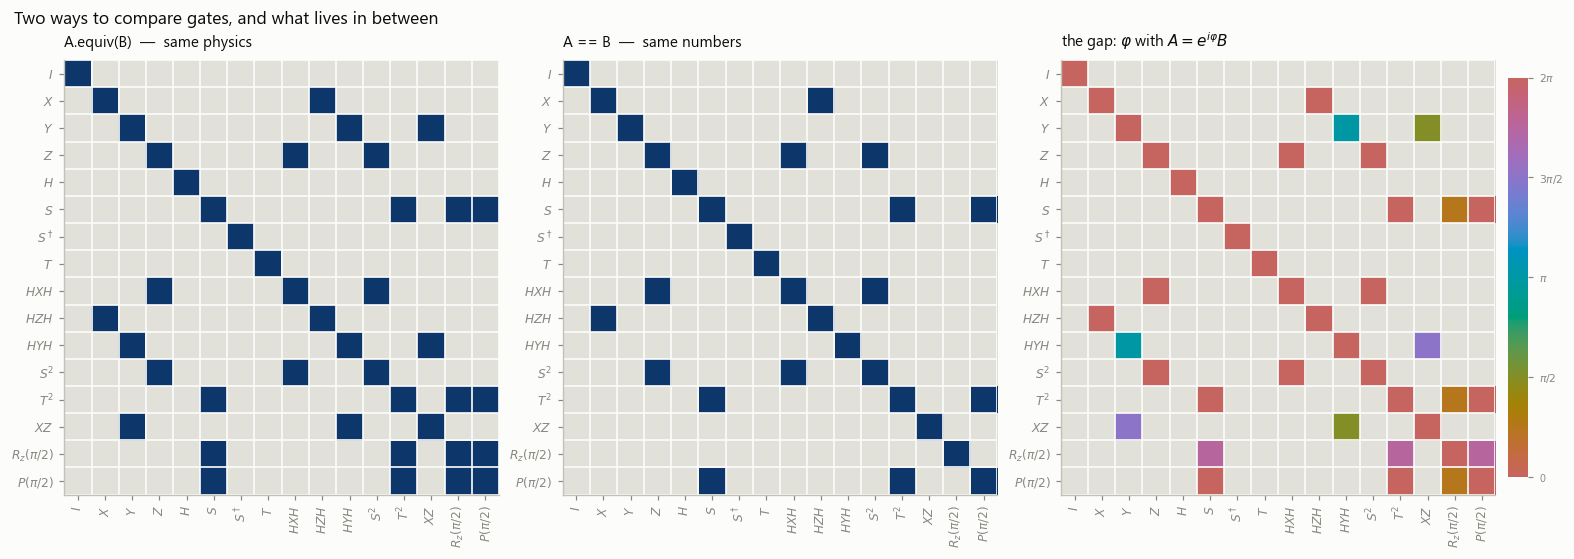

Identities discovered (equivalent pairs, off the diagonal):
         A          B    exact?   phase A = e^(i phi) B
         X        HZH      True   phi = -0.000 pi
         Y        HYH     False   phi = -1.000 pi
         Y         XZ     False   phi = +0.500 pi
         Z        HXH      True   phi = -0.000 pi
         Z         SS      True   phi = -0.000 pi
         S         TT      True   phi = -0.000 pi
         S   Rz(pi/2)     False   phi = +0.250 pi
         S    P(pi/2)      True   phi = +0.000 pi
       HXH         SS      True   phi = -0.000 pi
       HYH         XZ     False   phi = -0.500 pi
        TT   Rz(pi/2)     False   phi = +0.250 pi
        TT    P(pi/2)      True   phi = +0.000 pi
  Rz(pi/2)    P(pi/2)     False   phi = -0.250 pi

pairs equivalent but NOT equal: 6   (that is what global phase costs you)


In [4]:
EXPR = [
    ("I",      r"$I$",              lambda q: q.id(0)),
    ("X",      r"$X$",              lambda q: q.x(0)),
    ("Y",      r"$Y$",              lambda q: q.y(0)),
    ("Z",      r"$Z$",              lambda q: q.z(0)),
    ("H",      r"$H$",              lambda q: q.h(0)),
    ("S",      r"$S$",              lambda q: q.s(0)),
    ("Sdg",    r"$S^\dagger$",      lambda q: q.sdg(0)),
    ("T",      r"$T$",              lambda q: q.t(0)),
    ("HXH",    r"$HXH$",            lambda q: (q.h(0), q.x(0), q.h(0))),
    ("HZH",    r"$HZH$",            lambda q: (q.h(0), q.z(0), q.h(0))),
    ("HYH",    r"$HYH$",            lambda q: (q.h(0), q.y(0), q.h(0))),
    ("SS",     r"$S^2$",            lambda q: (q.s(0), q.s(0))),
    ("TT",     r"$T^2$",            lambda q: (q.t(0), q.t(0))),
    ("XZ",     r"$XZ$",             lambda q: (q.z(0), q.x(0))),   # Z first
    ("Rz(pi/2)", r"$R_z(\pi/2)$",   lambda q: q.rz(np.pi / 2, 0)),
    ("P(pi/2)",  r"$P(\pi/2)$",     lambda q: q.p(np.pi / 2, 0)),
]

OPS = [(nm, tex, Operator(one_gate(b))) for nm, tex, b in EXPR]
n = len(OPS)

EQUIV = np.array([[a.equiv(b) for _, _, b in OPS] for _, _, a in OPS])
EXACT = np.array([[a == b for _, _, b in OPS] for _, _, a in OPS])

# For each equivalent pair, recover the phase: <A,B> = Tr(A* B) has argument
# -phi when A = e^{i phi} B, so one trace hands us the whole answer.
PHI = np.zeros((n, n), dtype=complex)
for i, (_, _, a) in enumerate(OPS):
    for j, (_, _, b) in enumerate(OPS):
        if EQUIV[i, j]:
            PHI[i, j] = np.exp(-1j * np.angle(np.trace(dag(a.data) @ b.data)))

texs = [t for _, t, _ in OPS]
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.9))
for ax, M, title in [
        (axes[0], EQUIV.astype(float), "A.equiv(B)  —  same physics"),
        (axes[1], EXACT.astype(float), "A == B  —  same numbers"),
        (axes[2], PHI, r"the gap: $\varphi$ with $A = e^{i\varphi}B$")]:
    grid.matrix(ax, M, part="phase" if M.dtype == complex else "nonzero",
                labels=texs, cbar=(M.dtype == complex))
    ax.set_title(title, loc="left", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_xticklabels(texs, rotation=90, fontsize=8)
    ax.set_yticklabels(texs, fontsize=8)
fig.suptitle("Two ways to compare gates, and what lives in between",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("Identities discovered (equivalent pairs, off the diagonal):")
print(f"{'A':>10} {'B':>10}   {'exact?':>7}   phase A = e^(i phi) B")
for i in range(n):
    for j in range(i + 1, n):
        if not EQUIV[i, j]:
            continue
        phi = np.angle(PHI[i, j])
        print(f"{OPS[i][0]:>10} {OPS[j][0]:>10}   {str(bool(EXACT[i, j])):>7}   "
              f"phi = {phi/np.pi:+.3f} pi")

print(f"\npairs equivalent but NOT equal: {int((EQUIV & ~EXACT).sum()) // 2}"
      f"   (that is what global phase costs you)")

Read the printout as a list of theorems the computer just found for you.

**$HXH = Z$ and $HZH = X$, exactly.** $H$ conjugates $X$ into $Z$ and back —
which is the statement that $H$ swaps the $x$ and $z$ axes of the sphere, and
therefore swaps the computational basis with the $|{\pm}\rangle$ basis. Every
"measure in the X basis" recipe in the repo is this identity.

**$S^2 = Z$ and $T^2 = S$, exactly.** Two quarter-turns make a half-turn. The
$Z$/$S$/$T$ family really is one rotation at three strengths.

**$HYH$ and $Y$ are equivalent but not equal**, with $\varphi = \pi$: $HYH = -Y$.
$H$ swaps $\hat x$ and $\hat z$ and therefore *reverses* $\hat y$ to keep the
frame right-handed. On the sphere it is the same rotation; in the matrix there is
a minus sign.

**$XZ$ and $Y$ likewise**, at $\varphi = -\pi/2$: $XZ = -iY$. A03 made the same
point from the other end — $X$ and $Z$ anticommute, so $XZ$ and $ZX$ differ by
$-1$ and are the *same rotation* despite having the largest commutator in the
gate set. A non-zero commutator does not imply a visible difference.

**$R_z(\pi/2)$, $S$ and $P(\pi/2)$ all agree — but only two of the three are
equal.** `p` and `s` produce identical matrices; `rz` carries $e^{-i\pi/4}$. That
is the crack the rest of this notebook lives in.

## 3. $R_z$ versus $P$: the same rotation, written twice

$$R_z(\theta)=\begin{pmatrix}e^{-i\theta/2}&0\\0&e^{i\theta/2}\end{pmatrix},
\qquad
P(\theta)=\begin{pmatrix}1&0\\0&e^{i\theta}\end{pmatrix}
= e^{i\theta/2}R_z(\theta).$$

Both multiply the $|1\rangle$ amplitude by $e^{i\theta}$ *relative to*
$|0\rangle$. That relative phase is the physics. Where the two conventions put
the absolute phase is bookkeeping — $R_z$ splits it symmetrically so that
$R_z(\theta) = \exp(-i\theta Z/2)$ comes out clean, $P$ dumps it all on
$|1\rangle$ so that $P(\pi) = Z$ on the nose.

### Figure 3 — identical on the sphere, different in the bars

Left: both gates applied to the same generic state, drawn on one sphere. The
orange dashed track is $P$; it lies exactly on top of the blue $R_z$ track,
which is why you can only see one arc.

Middle and right: the amplitudes of $R_z(\theta)|+\rangle$ and
$P(\theta)|+\rangle$ in this repo's signature plot — height is $|$amplitude$|$,
fill colour is $\arg($amplitude$)$, and the clock hand repeats the phase in a
channel that survives colour-vision deficiency.

**The bar heights are identical and the colours are not.** Take that seriously,
because it is a criticism of our own plot: `amp_bars` encodes *absolute* phase,
and absolute phase is not observable. What matters is the phase *difference*
between the bars — the angle between the two clock hands — and that is the same
in both panels. Same rotation of the hands, different clock face.

Rz(2pi/3) = [0.5-0.866j 0.5+0.866j]
P (2pi/3) = [ 1. +0.j    -0.5+0.866j]

Operator(rz) == Operator(p)      -> False
Operator(rz).equiv(Operator(p))  -> True
ratio P/Rz (entrywise)           -> [0.5+0.866025j 0.5+0.866025j]  = e^(i theta/2), one number, both entries

same Bloch rotation -> True

Rz|+> = [0.3536-0.6124j 0.3536+0.6124j]
P |+> = [ 0.7071+0.j     -0.3536+0.6124j]
probabilities identical -> True
relative phase arg(a1) - arg(a0): Rz +2.094395    P +2.094395


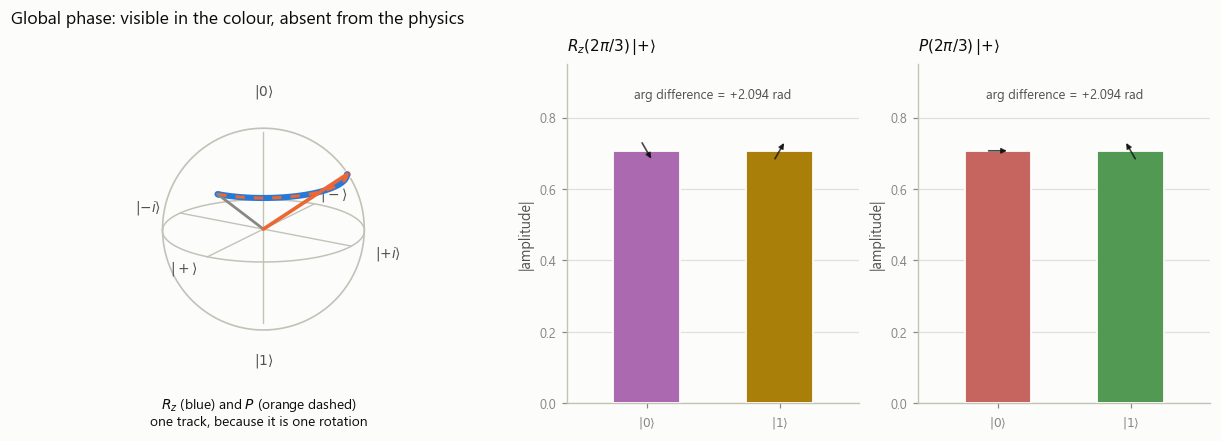

In [5]:
theta = 2 * np.pi / 3

rz_qc, p_qc = one_gate(lambda q: q.rz(theta, 0)), one_gate(lambda q: q.p(theta, 0))
Urz, Up = Operator(rz_qc), Operator(p_qc)

print("Rz(2pi/3) =", np.round(np.diag(Urz.data), 4))
print("P (2pi/3) =", np.round(np.diag(Up.data), 4))
print("\nOperator(rz) == Operator(p)      ->", Urz == Up)
print("Operator(rz).equiv(Operator(p))  ->", Urz.equiv(Up))
print("ratio P/Rz (entrywise)           ->",
      np.round(np.diag(Up.data) / np.diag(Urz.data), 6),
      " = e^(i theta/2), one number, both entries")
print("\nsame Bloch rotation ->",
      np.allclose(bloch_rotation(Urz.data), bloch_rotation(Up.data)))

plus = Statevector(one_gate(lambda q: q.h(0)))
out_rz, out_p = plus.evolve(Urz).data, plus.evolve(Up).data
print("\nRz|+> =", np.round(out_rz, 4))
print("P |+> =", np.round(out_p, 4))
print("probabilities identical ->",
      np.allclose(np.abs(out_rz) ** 2, np.abs(out_p) ** 2))
print("relative phase arg(a1) - arg(a0):",
      f"Rz {np.angle(out_rz[1]) - np.angle(out_rz[0]):+.6f}",
      f"   P {np.angle(out_p[1]) - np.angle(out_p[0]):+.6f}")

fig = plt.figure(figsize=(11.0, 3.9))
gs = fig.add_gridspec(1, 3, width_ratios=[1.45, 0.85, 0.85])

axb = fig.add_subplot(gs[0, 0], projection="3d")
bloch_frame(axb, zoom=1.52)
nv_rz, th_rz = axis_angle(Urz.data)
nv_p, th_p = axis_angle(Up.data)
track_rz = np.array([rodrigues(nv_rz, t, r0) for t in np.linspace(0, th_rz, 90)])
track_p = np.array([rodrigues(nv_p, t, r0) for t in np.linspace(0, th_p, 90)])
axb.plot(track_rz[:, 0], track_rz[:, 1], track_rz[:, 2], color=style.BLUE,
         lw=4.0, zorder=5, solid_capstyle="round")
axb.plot(track_p[:, 0], track_p[:, 1], track_p[:, 2], color=style.ORANGE,
         lw=2.0, ls=(0, (3, 3)), zorder=6)
bloch.vector(axb, r0, color=style.MUTED, lw=1.8)
bloch.vector(axb, rodrigues(nv_rz, th_rz, r0), color=style.ORANGE, lw=2.4)
bloch.label(axb, r"$R_z$ (blue) and $P$ (orange dashed)" + "\n"
                 "one track, because it is one rotation", y=0.02, size=9.0)

for k, (ax_i, lab, vec) in enumerate([
        (1, r"$R_z(2\pi/3)\,|{+}\rangle$", out_rz),
        (2, r"$P(2\pi/3)\,|{+}\rangle$", out_p)]):
    ax = fig.add_subplot(gs[0, ax_i])
    grid.amp_bars(ax, vec, ylim=0.95, bar_width=0.5)
    ax.set_title(lab, loc="left", fontsize=10)
    ax.text(0.5, 0.90,
            f"arg difference = {np.angle(vec[1]) - np.angle(vec[0]):+.3f} rad",
            transform=ax.transAxes, ha="center", fontsize=8.5,
            color=style.INK_2)
fig.suptitle("Global phase: visible in the colour, absent from the physics",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

## 4. Why `equiv` is the right default

It would be easy to read `equiv` as a convenience — a fuzzy comparison for people
who cannot be bothered to normalise. It is the opposite. `equiv` is the
comparison that matches the theory, and `==` is the one that leaks an
implementation detail.

The argument is short. A measurement outcome probability is
$|\langle m | \psi\rangle|^2$. Replace $|\psi\rangle$ with
$e^{i\varphi}|\psi\rangle$ and the modulus squared eats the phase. There is no
experiment — not one, ever — that returns a different answer. Two states
differing by a global phase are not two states; they are one state with two
names.

So when Qiskit reports `Operator(rz) == Operator(p)` as `False`, it is telling
you something true about the arrays and nothing about the world. `equiv` is the
one to reach for when you want to know whether your optimised circuit still does
the job.

In [6]:
# Global phase is invisible to every measurement, checked rather than asserted.
probe = Statevector(one_gate(lambda q: q.ry(1.1, 0)))
for phi in rng.uniform(0, 2 * np.pi, 4):
    shifted = Statevector(np.exp(1j * phi) * probe.data)
    same_probs = np.allclose(probe.probabilities(), shifted.probabilities())
    same_bloch = np.allclose(bloch_vector(probe.data), bloch_vector(shifted.data))
    same_expect = all(
        np.isclose(probe.expectation_value(Operator(G)),
                   shifted.expectation_value(Operator(G)))
        for G in (XGate(), YGate(), ZGate()))
    print(f"phase e^(i{phi:5.3f}):  probabilities equal {same_probs},"
          f"  Bloch vector equal {same_bloch},"
          f"  <X>,<Y>,<Z> equal {same_expect}")

print("\nQiskit tracks the phase anyway - QuantumCircuit.global_phase:")
for label, qc in [("rz(2pi/3)", rz_qc), ("p(2pi/3)", p_qc)]:
    tqc = transpile(qc, basis_gates=["rz", "sx", "x"], optimization_level=1,
                    seed_transpiler=SEED)
    print(f"  {label:>10} -> transpiled global_phase = {tqc.global_phase:+.6f}"
          f"   exact match after transpile: {Operator(tqc) == Operator(qc)}")
print("\nThe transpiler bookkeeps global phase to the last bit. Section 5"
      " is why it bothers.")

phase e^(i4.099):  probabilities equal True,  Bloch vector equal True,  <X>,<Y>,<Z> equal True
phase e^(i2.320):  probabilities equal True,  Bloch vector equal True,  <X>,<Y>,<Z> equal True
phase e^(i2.994):  probabilities equal True,  Bloch vector equal True,  <X>,<Y>,<Z> equal True
phase e^(i4.858):  probabilities equal True,  Bloch vector equal True,  <X>,<Y>,<Z> equal True

Qiskit tracks the phase anyway - QuantumCircuit.global_phase:
   rz(2pi/3) -> transpiled global_phase = +0.000000   exact match after transpile: True
    p(2pi/3) -> transpiled global_phase = +1.047198   exact match after transpile: True

The transpiler bookkeeps global phase to the last bit. Section 5 is why it bothers.


## 5. Honest limits — global phase stops being global

Everything above says global phase does not matter. Here is where that stops
being true, and it is not an edge case: it is the mechanism behind phase
kickback (A08), quantum phase estimation (A11/B22) and Shor's algorithm.

**Controlling a gate promotes its global phase to a relative phase.**

A controlled gate applies $U$ on the branch where the control is $|1\rangle$ and
does nothing on the branch where it is $|0\rangle$. If $U$ carries a factor
$e^{i\varphi}$, that factor now multiplies *one branch of a superposition and
not the other*. It is no longer a phase on the whole state — it is a phase
*between* two parts of the state, and phases between parts of a state are
exactly what interference measures.

So: `Operator(rz).equiv(Operator(p))` is `True`, and
`Operator(crz).equiv(Operator(cp))` is `False`. The equivalence is destroyed by
an operation that was supposed to be a mere wrapper.

### Figure 4 — same gate, controlled, genuinely different

Top row: the phase of every entry of the two $4\times4$ controlled operators.
Both are diagonal; the difference is *which* diagonal entries carry phase.
Bottom row: the state after applying each to $|{+}{+}\rangle$. Bar heights
identical, phase pattern different — and this time the difference is not
global, because there is no single number you can factor out of all four
amplitudes.

*(Endianness, per the repo convention: little-endian, so index $i$ maps to a
bitstring with qubit 0 as the rightmost character. The control is qubit 0.)*

diag(controlled-Rz) = [1. +0.j    0.5-0.866j 1. +0.j    0.5+0.866j]
diag(controlled-P ) = [ 1. +0.j     1. +0.j     1. +0.j    -0.5+0.866j]

Single qubit:  Operator(rz).equiv(Operator(p))   -> True
Controlled  :  Operator(crz).equiv(Operator(cp)) -> False

Qiskit's own cp gate == controlling p ourselves: True


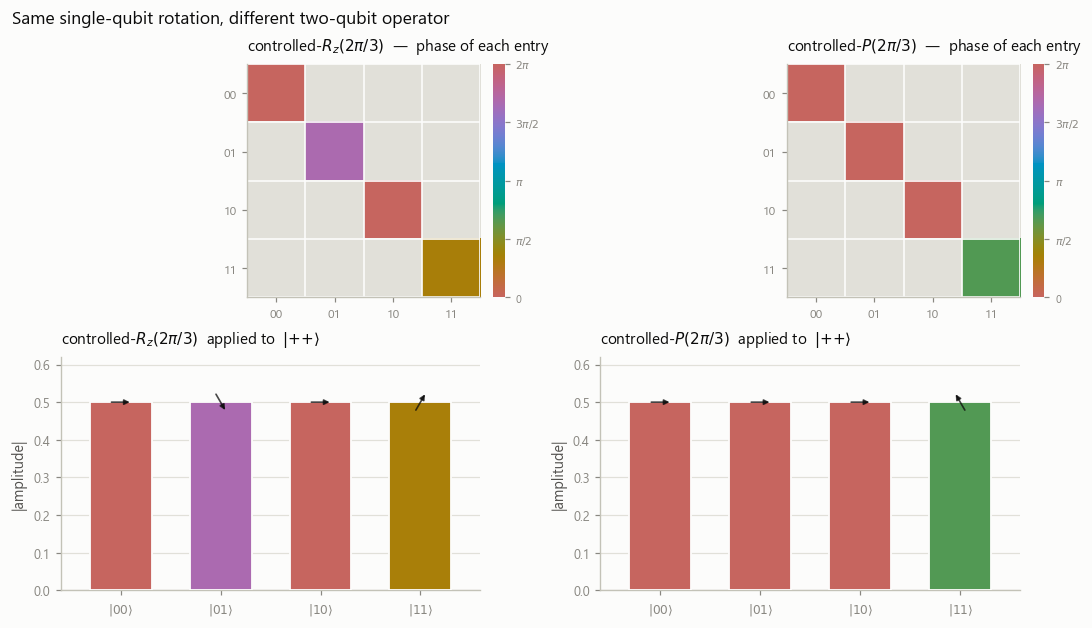


after controlled-Rz: [0.5 +0.j    0.25-0.433j 0.5 +0.j    0.25+0.433j]
after controlled-P : [ 0.5 +0.j     0.5 +0.j     0.5 +0.j    -0.25+0.433j]
measurement probabilities in this basis are still identical -> True


In [7]:
def controlled(gate):
    """Two-qubit circuit: control on qubit 0, ``gate`` on qubit 1.

    ``Gate.control(1)`` is the general wrapper - it works on any gate, named or
    not. (Building it instead from ``one_gate(...).to_gate().control(1)`` also
    produces the right operator, but wraps an anonymous subcircuit that Aer
    cannot execute, so the library gates are what we hand to the simulator.)
    """
    qc = QuantumCircuit(2)
    qc.append(gate.control(1), [0, 1])
    return qc


crz_qc, cp_qc = controlled(RZGate(theta)), controlled(PhaseGate(theta))
CRZ, CP = Operator(crz_qc), Operator(cp_qc)

print("diag(controlled-Rz) =", np.round(np.diag(CRZ.data), 4))
print("diag(controlled-P ) =", np.round(np.diag(CP.data), 4))
print("\nSingle qubit:  Operator(rz).equiv(Operator(p))   ->", Urz.equiv(Up))
print("Controlled  :  Operator(crz).equiv(Operator(cp)) ->", CRZ.equiv(CP))
builtin_cp = QuantumCircuit(2)
builtin_cp.cp(theta, 0, 1)              # the library gate, not our wrapper
print("\nQiskit's own cp gate == controlling p ourselves:",
      Operator(builtin_cp) == CP)

pp = Statevector(one_gate(lambda q: q.h(0))).tensor(
    Statevector(one_gate(lambda q: q.h(0))))     # |+>|+>, all amplitudes 1/2

fig, axes = plt.subplots(2, 2, figsize=(9.8, 5.6))
for j, (name, U2) in enumerate([(r"controlled-$R_z(2\pi/3)$", CRZ),
                                (r"controlled-$P(2\pi/3)$", CP)]):
    grid.matrix(axes[0, j], U2.data, part="phase", annot=False)
    axes[0, j].set_title(name + "  —  phase of each entry", loc="left",
                         fontsize=10)
    grid.amp_bars(axes[1, j], pp.evolve(U2).data, ylim=0.62, bar_width=0.62)
    axes[1, j].set_title(name + r"  applied to  $|{+}{+}\rangle$", loc="left",
                         fontsize=10)
fig.suptitle("Same single-qubit rotation, different two-qubit operator",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("\nafter controlled-Rz:", np.round(pp.evolve(CRZ).data, 4))
print("after controlled-P :", np.round(pp.evolve(CP).data, 4))
print("measurement probabilities in this basis are still identical ->",
      np.allclose(pp.evolve(CRZ).probabilities(), pp.evolve(CP).probabilities()))

Those last two lines matter. In the computational basis the two states are
*still* indistinguishable — same four probabilities. The difference is entirely
in the phases, and phases only become visible when you interfere them. The next
section does exactly that, and then counts.

## 6. Making it measurable: phase kickback, with a `SamplerV2`

The circuit is the smallest interferometer there is:

1. put the control in $|+\rangle$ with an $H$,
2. put the target in $|1\rangle$ — an **eigenstate** of both $R_z$ and $P$,
3. apply the controlled gate,
4. undo the $H$ on the control and measure it.

Because $|1\rangle$ is an eigenstate, the gate does not change the target at
all; it only multiplies it by its eigenvalue. That eigenvalue is $e^{i\theta}$
for $P(\theta)$ but $e^{i\theta/2}$ for $R_z(\theta)$ — the very factor
`equiv` told us to ignore. The eigenvalue gets *kicked back* onto the control,
and the final $H$ turns it into a probability:

### Figure 5 — the experiment

$$P(\text{control} = 1) = \sin^2\!\left(\frac{\lambda}{2}\right),
\qquad \lambda = \begin{cases}\theta & \text{for } P(\theta)\\[2pt]
\theta/2 & \text{for } R_z(\theta).\end{cases}$$

Two different curves. Not two different conventions for the same curve —
two different experimental outcomes, from gates that `equiv` calls the same.

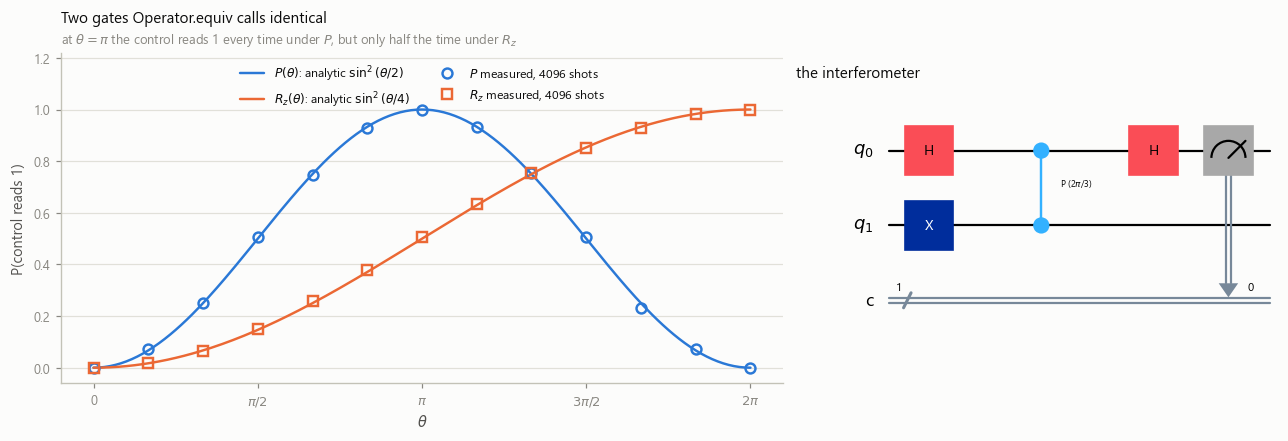

     theta  P(theta) meas   analytic | Rz(theta) meas   analytic
    0.00 pi         0.0000     0.0000 |         0.0000     0.0000
    0.50 pi         0.5049     0.5000 |         0.1506     0.1464
    1.00 pi         1.0000     1.0000 |         0.5044     0.5000
    1.50 pi         0.5071     0.5000 |         0.8511     0.8536
    2.00 pi         0.0000     0.0000 |         1.0000     1.0000

largest gap between the two curves: 1.0   (shot noise at 4096 shots is about 0.008)


In [8]:
def kickback(gate):
    """Control in |+>, target in |1>, controlled-gate, un-H, measure control.

    The classical register is named "c" by repo convention, so the result comes
    back as ``result[i].data.c`` - ``measure_all()`` would name it "meas" and
    every access below would be an AttributeError.
    """
    qr, cr = QuantumRegister(2, "q"), ClassicalRegister(1, "c")
    qc = QuantumCircuit(qr, cr)
    qc.h(0)
    qc.x(1)                                  # target into the eigenstate |1>
    qc.append(gate.control(1), [0, 1])
    qc.h(0)
    qc.measure(0, 0)
    return qc


SHOTS = 4096
sweep = np.linspace(0, 2 * np.pi, 13)
jobs = ([kickback(PhaseGate(th)) for th in sweep]
        + [kickback(RZGate(th)) for th in sweep])

res = backends.sampler(shots=SHOTS, seed=SEED).run(jobs).result()
frac = np.array([r.data.c.get_counts().get("1", 0) / SHOTS for r in res])
meas_p, meas_rz = frac[:len(sweep)], frac[len(sweep):]

fine = np.linspace(0, 2 * np.pi, 241)
fig = plt.figure(figsize=(11.6, 3.9))
gsk = fig.add_gridspec(1, 2, width_ratios=[1.5, 1.0])

axk = fig.add_subplot(gsk[0, 0])
axk.plot(fine, np.sin(fine / 2) ** 2, color=style.BLUE, lw=1.6,
         label=r"$P(\theta)$: analytic $\sin^2(\theta/2)$")
axk.plot(fine, np.sin(fine / 4) ** 2, color=style.ORANGE, lw=1.6,
         label=r"$R_z(\theta)$: analytic $\sin^2(\theta/4)$")
axk.plot(sweep, meas_p, ls="none", marker="o", ms=6.5, mfc="none",
         mec=style.BLUE, mew=1.6, label=rf"$P$ measured, {SHOTS} shots")
axk.plot(sweep, meas_rz, ls="none", marker="s", ms=6.0, mfc="none",
         mec=style.ORANGE, mew=1.6, label=rf"$R_z$ measured, {SHOTS} shots")
axk.set_xticks(np.linspace(0, 2 * np.pi, 5))
axk.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axk.set_xlabel(r"$\theta$")
axk.set_ylabel("P(control reads 1)")
axk.set_ylim(-0.06, 1.22)
axk.legend(loc="upper center", ncol=2, fontsize=8)
# The curves cross and the legend takes the top, so the punchline goes in the
# header rather than as a callout inside the data area.
axk.set_title("Two gates Operator.equiv calls identical", loc="left",
              fontsize=10, pad=20)
axk.text(0.0, 1.015, r"at $\theta=\pi$ the control reads 1 every time under "
                     r"$P$, but only half the time under $R_z$",
         transform=axk.transAxes, ha="left", va="bottom", fontsize=8.5,
         color=style.MUTED)

axc = fig.add_subplot(gsk[0, 1])
kickback(PhaseGate(theta)).draw(
    "mpl", ax=axc, style={"backgroundcolor": style.SURFACE})
axc.set_title("the interferometer", loc="left", fontsize=10)
plt.show()

print(f"{'theta':>10} {'P(theta) meas':>14} {'analytic':>10}"
      f" | {'Rz(theta) meas':>14} {'analytic':>10}")
for th, mp, mr in list(zip(sweep, meas_p, meas_rz))[::3]:
    print(f"{th/np.pi:8.2f} pi {mp:14.4f} {np.sin(th/2)**2:10.4f}"
          f" | {mr:14.4f} {np.sin(th/4)**2:10.4f}")
print("\nlargest gap between the two curves:",
      round(float(np.abs(meas_p - meas_rz).max()), 4),
      "  (shot noise at 4096 shots is about 0.008)")

That is the whole lesson in one figure. The two gates are the same rotation of
one qubit; controlled, they are different instruments, and 4096 shots tell them
apart without ambiguity.

The practical rule: **`equiv` is the right comparison for a circuit you are
going to run as-is, and the wrong one for a subcircuit you are going to
control.** If you are writing a routine that might be wrapped in a
`.control()` — and in phase estimation everything is — the global phase is part
of your specification, and you want `==`. This is why Qiskit's transpiler keeps
`QuantumCircuit.global_phase` to full precision instead of throwing it away.

## 7. Deep dive — every single-qubit gate is one `U`

*Skip on a first read.*

The gate set in Figure 1 has twelve entries, but it does not need to. Every
$2\times2$ unitary can be written

$$U = e^{i\alpha}\,R_z(\phi)\,R_y(\theta)\,R_z(\lambda),$$

three rotations and a phase — the Euler decomposition, and the reason
`u(θ, φ, λ)` has exactly three parameters. Qiskit exposes it as
`OneQubitEulerDecomposer`, and the transpiler uses it constantly: hardware does
not implement $H$ or $T$, it implements a small basis like
$\{R_z, \sqrt{X}, X\}$, and every gate you write is rewritten into that basis
before it runs.

The figure below takes three gates and shows what actually reaches the machine.
Note the `global phase:` annotation on the transpiled circuits — Qiskit prints
it because, as Section 5 established, it is not always ignorable.

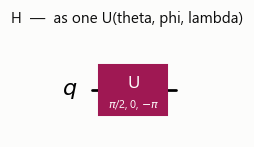

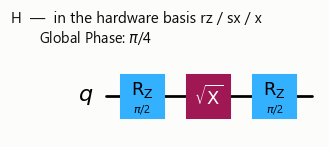

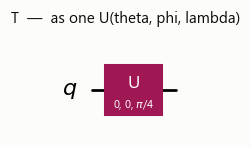

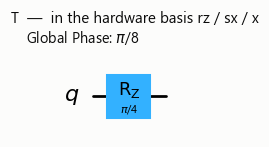

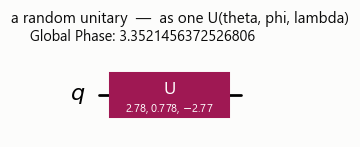

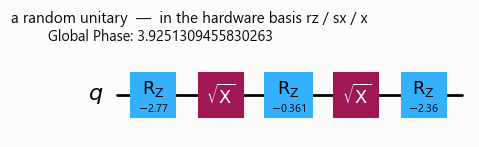

              gate      U params (theta, phi, lambda)   exact?   equiv?  hw depth
                 H          [ 1.5708, 0.    ,-3.1416]     True     True  3
                 T             [0.    ,0.    ,0.7854]     True     True  1
  a random unitary          [ 2.7806, 0.778 ,-2.7736]     True     True  5


In [9]:
decomp = OneQubitEulerDecomposer(basis="U")

targets = [("H", one_gate(lambda q: q.h(0))),
           ("T", one_gate(lambda q: q.t(0))),
           ("a random unitary", None)]

# A Haar-ish random single-qubit unitary, seeded like everything else.
M = rng.normal(size=(2, 2)) + 1j * rng.normal(size=(2, 2))
Q, Rr = np.linalg.qr(M)
Q = Q * (np.diag(Rr) / np.abs(np.diag(Rr)))
rand_qc = QuantumCircuit(1)
rand_qc.unitary(Q, 0)
targets[2] = ("a random unitary", rand_qc)

# Each circuit is drawn into its OWN figure. The mpl drawer sizes its axes to
# the circuit, so forcing several into a shared subplot grid rescales the gate
# boxes independently and clips their parameter text - the drawings come out
# unreadable at three different scales. One figure each, displayed in turn.
for name, qc in targets:
    for label, drawn in [("as one U(theta, phi, lambda)",
                          decomp(Operator(qc).data)),
                         ("in the hardware basis rz / sx / x",
                          transpile(qc, basis_gates=["rz", "sx", "x"],
                                    optimization_level=1,
                                    seed_transpiler=SEED))]:
        f = drawn.draw("mpl", style={"backgroundcolor": style.SURFACE},
                       scale=0.9)
        f.suptitle(f"{name}  —  {label}", x=0.02, y=1.12, ha="left",
                   fontsize=10, color=style.INK)
        display(f)
        plt.close(f)

print(f"{'gate':>18} {'U params (theta, phi, lambda)':>34}  "
      f"{'exact?':>7}  {'equiv?':>7}  hw depth")
for name, qc in targets:
    U = Operator(qc)
    euler = decomp(U.data)
    params = [float(p) for inst in euler.data for p in inst.operation.params]
    hw = transpile(qc, basis_gates=["rz", "sx", "x"], optimization_level=1,
                   seed_transpiler=SEED)
    print(f"{name:>18} {np.array2string(np.round(params, 4), separator=','):>34}"
          f"  {str(Operator(euler) == U):>7}"
          f"  {str(Operator(euler).equiv(U)):>7}  {hw.depth()}")

### Figure 6 — the cost of each gate, in hardware instructions

Same fourteen gates as Section 1, each pushed through the transpiler into the
$\{R_z, \sqrt{X}, X\}$ basis a superconducting device actually offers.

Left: how many of each instruction comes out. Note that $Z$, $S$, $S^\dagger$,
$T$, $T^\dagger$ and $R_z$ all collapse to a **single `rz`** — and on real
hardware an `rz` is usually *free*, implemented by shifting the phase of the
next control pulse rather than by emitting one. The gates that cost something
are the ones that move the state off the $z$ axis.

Right: the global phase each transpiled circuit ends up carrying. It is rarely
zero — and per Section 5, it is not decoration. If the transpiler dropped it,
every one of these gates would become the wrong gate the moment it was
controlled.

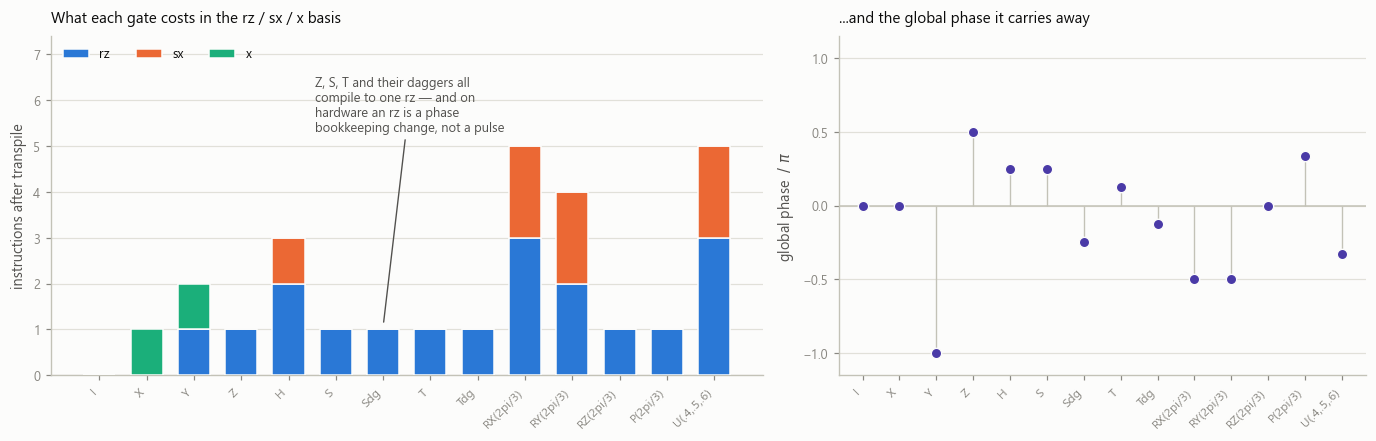

        gate   rz  sx   x   global phase / pi
           I    0   0   0   +0.0000
           X    0   0   1   +0.0000
           Y    1   0   1   -1.0000
           Z    1   0   0   +0.5000
           H    2   1   0   +0.2500
           S    1   0   0   +0.2500
         Sdg    1   0   0   -0.2500
           T    1   0   0   +0.1250
         Tdg    1   0   0   -0.1250
   RX(2pi/3)    3   2   0   -0.5000
   RY(2pi/3)    2   2   0   -0.5000
   RZ(2pi/3)    1   0   0   +0.0000
    P(2pi/3)    1   0   0   +0.3333
 U(.4,.5,.6)    3   2   0   -0.3249


In [10]:
BASIS = ["rz", "sx", "x"]
rows = []
for name, build, _ in CATALOGUE:
    hw = transpile(one_gate(build), basis_gates=BASIS, optimization_level=1,
                   seed_transpiler=SEED)
    counts = hw.count_ops()
    rows.append((name, [counts.get(g, 0) for g in BASIS],
                 float(hw.global_phase)))

names = [r[0] for r in rows]
counts = np.array([r[1] for r in rows])
phases = np.array([r[2] for r in rows])
# Global phase is defined mod 2 pi; fold to (-pi, pi] so the plot is symmetric.
phases = (phases + np.pi) % (2 * np.pi) - np.pi
xs = np.arange(len(rows))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.9),
                         gridspec_kw={"width_ratios": [1.35, 1.0]})

bottom = np.zeros(len(rows))
for k, (g, col) in enumerate(zip(BASIS, [style.BLUE, style.ORANGE, style.AQUA])):
    axes[0].bar(xs, counts[:, k], bottom=bottom, width=0.68, color=col,
                edgecolor=style.SURFACE, linewidth=1.0, zorder=3, label=g)
    bottom = bottom + counts[:, k]
axes[0].set_xticks(xs)
axes[0].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("instructions after transpile")
axes[0].set_ylim(0, max(bottom.max() * 1.48, 1))
axes[0].legend(loc="upper left", ncol=3, fontsize=8.5)
axes[0].set_title("What each gate costs in the rz / sx / x basis", loc="left",
                  fontsize=10)
grid.annotate(axes[0], "Z, S, T and their daggers all\ncompile to one rz — and "
                       "on\nhardware an rz is a phase\nbookkeeping change, "
                       "not a pulse",
              xy=(6.0, 1.06), xytext=(4.55, 5.9))

axes[1].axhline(0, color=style.AXIS, lw=1.0, zorder=2)
axes[1].vlines(xs, 0, phases / np.pi, color=style.AXIS, lw=0.9, zorder=2)
axes[1].scatter(xs, phases / np.pi, s=46, color=style.VIOLET, zorder=4,
                edgecolors=style.SURFACE, linewidths=0.9)
axes[1].set_xticks(xs)
axes[1].set_xticklabels(names, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel(r"global phase  $/\ \pi$")
axes[1].set_ylim(-1.15, 1.15)
axes[1].set_title("...and the global phase it carries away", loc="left",
                  fontsize=10)
plt.show()

print(f"{'gate':>12}  {'rz':>3} {'sx':>3} {'x':>3}   global phase / pi")
for (name, c, _), ph in zip(rows, phases):
    print(f"{name:>12}  {c[0]:>3} {c[1]:>3} {c[2]:>3}   {ph/np.pi:+.4f}")

Exact, not merely equivalent, in every row: `OneQubitEulerDecomposer` and the
transpiler both carry the leftover $e^{i\alpha}$ in `QuantumCircuit.global_phase`
rather than discarding it. If they discarded it, `.control()` would silently
produce the wrong two-qubit gate — which, now that you have seen Figure 4, you
can predict rather than have to be told.

## What this notebook glossed over

- **`Operator(qc)` builds the dense $2^n\times2^n$ matrix.** Fine here, hopeless
  past ~12 qubits. `equiv` on two 20-qubit circuits is not a strategy; the
  general problem of deciding circuit equivalence is QMA-complete.
- **`equiv` has tolerances.** It is `rtol`/`atol` underneath, so "equivalent"
  means "equivalent to within floating point". Two gates differing by
  $10^{-9}$ radians are reported equal; compose ten thousand of them and they
  are not. C27 measures how coherent errors accumulate.
- **Every number here came from an ideal simulator.** No decoherence, no gate
  infidelity, no readout error. On hardware the kickback curves in Figure 5
  would be visibly damped, and B26 is where that starts.
- **The Bloch picture is one qubit only.** Figure 1 is exact for a pure single
  qubit and has nothing to say about two. A03 and B18 both belabour this
  because it is the most common way people go wrong.
- **We only controlled a gate.** Global phase also becomes physical under
  `power()`, inside a `Parameter` sweep that gets differentiated, and in any
  context where a subcircuit's phase is compared against another branch.

## Checkpoint

Track B notebooks close by asserting against the Track A result they mirror.
Here that is A03: the matrices are rebuilt in raw NumPy, exactly the way A03
builds them, and compared against `Operator(qc).data` entry for entry.

In [11]:
# 1. THE cross-track assertion: every gate, hand-built the A03 way, equals
#    Operator(qc).data - including rotations at a non-trivial angle.
for name, build, hand in CATALOGUE:
    assert np.allclose(Operator(one_gate(build)).data, hand), name

# ...and at a spread of awkward angles, not just the one in the table.
for t in rng.uniform(-4 * np.pi, 4 * np.pi, 25):
    assert np.allclose(Operator(one_gate(lambda q: q.rx(t, 0))).data, rot(X, t))
    assert np.allclose(Operator(one_gate(lambda q: q.ry(t, 0))).data, rot(Y, t))
    assert np.allclose(Operator(one_gate(lambda q: q.rz(t, 0))).data, rot(Z, t))
    assert np.allclose(Operator(one_gate(lambda q: q.p(t, 0))).data, P_gate(t))
for a, b, c in rng.uniform(-np.pi, np.pi, size=(10, 3)):
    assert np.allclose(Operator(one_gate(lambda q: q.u(a, b, c, 0))).data,
                       U_gate(a, b, c))

# 2. Statevectors agree too, not just operators (little-endian contract).
for name, build, hand in CATALOGUE:
    sv = Statevector(one_gate(build)).data
    assert np.allclose(sv, hand @ np.array([1, 0], dtype=complex)), name

# 3. Every gate is unitary and every one is a Bloch rotation.
for name, build, _ in CATALOGUE:
    U = Operator(one_gate(build)).data
    assert np.allclose(dag(U) @ U, I2), name
    R = bloch_rotation(U)
    assert np.allclose(R.T @ R, np.eye(3), atol=1e-10), name
    assert np.isclose(np.linalg.det(R), 1.0, atol=1e-10), name

# 4. The claim extended: 200 random unitaries are rotations as well.
for _ in range(200):
    Mr = rng.normal(size=(2, 2)) + 1j * rng.normal(size=(2, 2))
    Qr, Rr2 = np.linalg.qr(Mr)
    Qr = Qr * (np.diag(Rr2) / np.abs(np.diag(Rr2)))
    Rb = bloch_rotation(Qr)
    assert np.allclose(Rb.T @ Rb, np.eye(3), atol=1e-10)
    assert np.isclose(np.linalg.det(Rb), 1.0, atol=1e-10)

# 5. The identities the heatmap discovered, as assertions.
assert Operator(one_gate(lambda q: (q.h(0), q.x(0), q.h(0)))) == Operator(ZGate())
assert Operator(one_gate(lambda q: (q.h(0), q.z(0), q.h(0)))) == Operator(XGate())
assert Operator(one_gate(lambda q: (q.s(0), q.s(0)))) == Operator(ZGate())
assert Operator(one_gate(lambda q: (q.t(0), q.t(0)))) == Operator(SGate())
# HYH = -Y and XZ = -iY: equivalent, not equal.
hyh = Operator(one_gate(lambda q: (q.h(0), q.y(0), q.h(0))))
assert hyh.equiv(Operator(YGate())) and hyh != Operator(YGate())
assert np.allclose(hyh.data, -Y)
xz = Operator(one_gate(lambda q: (q.z(0), q.x(0))))
assert xz.equiv(Operator(YGate())) and np.allclose(xz.data, -1j * Y)

# 6. The heart of the notebook: equiv and == disagree exactly on global phase.
for t in rng.uniform(0.2, 3.0, 8):
    a = Operator(one_gate(lambda q: q.rz(t, 0)))
    b = Operator(one_gate(lambda q: q.p(t, 0)))
    assert a.equiv(b)
    assert a != b
    assert np.allclose(b.data, np.exp(1j * t / 2) * a.data)
    assert np.allclose(bloch_rotation(a.data), bloch_rotation(b.data))

# 7. ...and controlling the gate destroys the equivalence. The kicked-back
#    eigenvalues on the |1> branch differ by exactly the phase equiv discarded.
for t in rng.uniform(0.2, 3.0, 5):
    ca = Operator(controlled(RZGate(t)))
    cb = Operator(controlled(PhaseGate(t)))
    assert not ca.equiv(cb)
    # index 3 is |11>: control 1, target 1 - the branch the gate acts on.
    assert np.isclose(np.diag(cb.data)[3] / np.diag(ca.data)[3],
                      np.exp(1j * t / 2))
    ref = QuantumCircuit(2)
    ref.cp(t, 0, 1)
    assert Operator(ref) == cb

# 8. Global phase changes no probability, no expectation value, no Bloch vector.
base = Statevector(one_gate(lambda q: q.ry(0.9, 0)))
for phi in rng.uniform(0, 2 * np.pi, 10):
    shift = Statevector(np.exp(1j * phi) * base.data)
    assert np.allclose(base.probabilities(), shift.probabilities())
    assert np.allclose(bloch_vector(base.data), bloch_vector(shift.data))

# 9. The measured kickback curves match the analytic ones within shot noise.
#    5 sigma on 4096 shots is comfortably above the ~0.008 one-sigma scale.
tol = 5 * np.sqrt(0.25 / SHOTS)
assert np.abs(meas_p - np.sin(sweep / 2) ** 2).max() < tol
assert np.abs(meas_rz - np.sin(sweep / 4) ** 2).max() < tol
assert np.abs(meas_p - meas_rz).max() > 0.4      # and they really do differ

# 10. Transpilation preserves the operator exactly, global phase included.
for name, build, _ in CATALOGUE:
    qc = one_gate(build)
    tq = transpile(qc, basis_gates=["rz", "sx", "x"], optimization_level=1,
                   seed_transpiler=SEED)
    assert Operator(tq) == Operator(qc), name

print("B15 checkpoint passed.")

B15 checkpoint passed.


---

**Next:** [B16 — Measurement with SamplerV2](B16_Measurement_SamplerV2.ipynb).
Every gate in this notebook was reversible and deterministic. Measurement is
neither, and B16 shows the raw shot record — the actual randomness, not a bar
chart of it.